In [1]:
from torchvision.datasets import EuroSAT
import torch
from torchvision.transforms import v2
torch.manual_seed(1502)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE USED:", device)

main_tf = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])

DEVICE USED: cuda


Wrapper to transform only training data

In [2]:
train_tf = v2.Compose([
    v2.RandomCrop(size=64),
    v2.RandomVerticalFlip(),
    v2.RandomHorizontalFlip(),
    v2.RandomErasing(scale=[0.01, 0.33])
])


In [3]:
from torch.utils.data import Dataset

class TransformSubset(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, idx):
        x, y = self.subset[idx]
        return self.transform(x), y

    def __len__(self):
        return len(self.subset)

In [4]:
from torch.utils.data import random_split

data = EuroSAT(root="data", download=True, transform=main_tf)
train_data, test_data = random_split(data, lengths=[0.8, 0.2])
train_data = TransformSubset(train_data, train_tf)

100%|██████████| 94.3M/94.3M [00:00<00:00, 97.9MB/s]


In [14]:
print("IMAGE SIZE:", data[1][0].shape)
print("CLASSES:", len(data.classes), "\n" ,data.classes)

IMAGE SIZE: torch.Size([3, 64, 64])
CLASSES: 10 
 ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


Image shape: torch.Size([3, 64, 64])


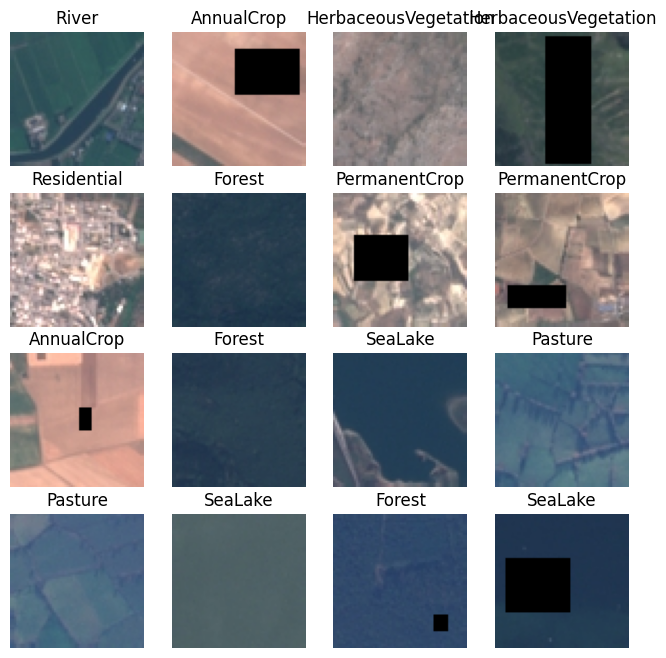

In [6]:
import matplotlib.pyplot as plt
from torchvision.transforms.functional import to_pil_image

print("Image shape:", train_data[0][0].shape)

class_names = data.classes
fig, ax = plt.subplots(4,4,figsize=(8,8))
k = torch.randint(1, 2000, (1,)).item()
for i in range(4):
    for j in range(4):
        image, label = train_data[k]
        ax[i, j].imshow(to_pil_image(image), cmap='grey')
        ax[i,j].axis(False)
        ax[i,j].set_title(class_names[int(label)])
        k += 1


In [7]:
from torch.utils.data import DataLoader
import torch
BATCH_SIZE = 128
train_dataloader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
test_dataloader = DataLoader(dataset=test_data, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)

In [8]:
from sklearn.metrics import accuracy_score

def train_step(model: torch.nn.Module, data_loader, loss_fn, optimizer,):
     loss_total = 0
     acc_total = 0
     model.train()
     for X, y in data_loader:
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        loss_total += loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
     loss_total /= len(data_loader)
     acc_total /= len(data_loader)
     return {"Loss": loss_total.item(), "Acc": acc_total}

def test_step(model: torch.nn.Module, data_loader, loss_fn):
    loss_total = 0
    acc_total = 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            X = X.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            y_pred = model(X)
            loss = loss_fn(y_pred, y)
            loss_total += loss
            acc_total += accuracy_score(y.cpu(), y_pred.cpu().argmax(dim=1))
        loss_total /= len(data_loader)
        acc_total /= len(data_loader)
        return {"Loss": loss_total.item(), "Acc": acc_total}


# Basic model
Here I try to use the same model as FashionMNIST to EuroSAT and evaluate perfomance

In [9]:
from torch import nn
from torchvision import transforms

class ConvBlock(nn.Module):
  def __init__(self, input_shape, hidden_units):
    """
    Passes X through two conv layer, batch, Relu, twice and ends with maxPool
    """
    super().__init__()
    self.conv_block = nn.Sequential(
                nn.Conv2d(in_channels=input_shape,
                            out_channels=hidden_units,
                            kernel_size=3,
                            stride=1,
                            padding=1),
                nn.BatchNorm2d(num_features=hidden_units),
                nn.ReLU(),
                nn.Conv2d(in_channels=hidden_units,
                            out_channels=hidden_units,
                            kernel_size=3,
                            stride=1,
                            padding=1),
                nn.BatchNorm2d(num_features=hidden_units),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2))

  def forward(self, x):
    return self.conv_block(x)

class ConvClassifier(nn.Module):
  #Flattens and classifies conv layer output
    def __init__(self, input_shape, hidden_units, output_shape):
        super().__init__()
        self.classifier = nn.Sequential(
                nn.Flatten(),
                nn.Linear(in_features=input_shape,
                          out_features=hidden_units),
                nn.Dropout(p=0.2),
                nn.Linear(in_features=hidden_units,
                          out_features=output_shape))
    def forward(self, x):
        return self.classifier(x)

class FashionClassifier(nn.Module):
    def __init__(self, input_shape, hidden_units, output_shape):
        super().__init__()

        self.conv_block_1 = ConvBlock(input_shape=input_shape, hidden_units=hidden_units)
        self.conv_block_2 = ConvBlock(input_shape=hidden_units, hidden_units=hidden_units*2)
        self.classifier_layer = ConvClassifier(input_shape=hidden_units*2*16*16, hidden_units=128, output_shape=output_shape)

    def forward(self, x):
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.classifier_layer(x)
        return x

In [10]:
model = FashionClassifier(input_shape=3, hidden_units=15, output_shape=len(class_names)).to(device)

In [11]:
from tqdm import tqdm

epochs = 30
optimizer = torch.optim.AdamW(params=model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()
train_loss_list = list()
test_loss_list = list()

for epoch in tqdm(range(epochs)):
    res_train = train_step(model=model,
                           data_loader=train_dataloader,
                           loss_fn=loss_fn,
                           optimizer=optimizer)
    train_loss_list.append(res_train['Loss'])
    res_test = test_step(model=model,
                           data_loader=test_dataloader,
                           loss_fn=loss_fn)
    test_loss_list.append(res_test['Loss'])
    print(f"EPOCH: {epoch} \n TRAIN Loss: {res_train['Loss']} \n TEST Loss: {res_test['Loss']}\n TEST Acc: {res_test['Acc']*100:.2f}%")

  3%|▎         | 1/30 [00:29<14:19, 29.65s/it]

EPOCH: 0 
 TRAIN Loss: 1.5435962677001953 
 TEST Loss: 1.0305743217468262
 TEST Acc: 67.44%


  7%|▋         | 2/30 [00:57<13:17, 28.49s/it]

EPOCH: 1 
 TRAIN Loss: 0.847142219543457 
 TEST Loss: 1.102124810218811
 TEST Acc: 64.67%


 10%|█         | 3/30 [01:21<11:57, 26.57s/it]

...

EPOCH: 27 
 TRAIN Loss: 0.24349462985992432 
 TEST Loss: 2.8245277404785156
 TEST Acc: 61.63%


 97%|█████████▋| 29/30 [13:33<00:24, 24.51s/it]

EPOCH: 28 
 TRAIN Loss: 0.24048911035060883 
 TEST Loss: 0.5408788323402405
 TEST Acc: 83.60%


100%|██████████| 30/30 [13:55<00:00, 27.86s/it]

EPOCH: 29 
 TRAIN Loss: 0.2356048971414566 
 TEST Loss: 0.7582598924636841
 TEST Acc: 81.03%


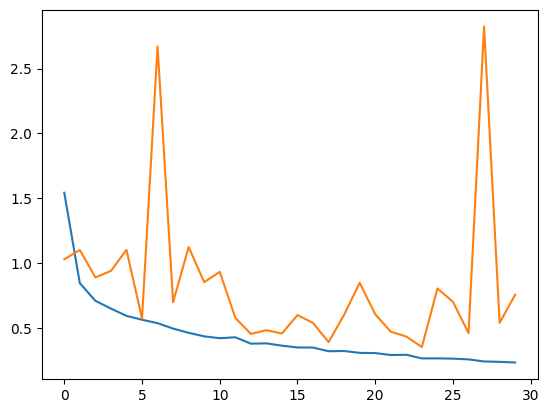

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.plot(train_loss_list)
ax.plot(test_loss_list)

#GoogLeNet

In [28]:
from torch.nn.modules.pooling import MaxPool2d
class Head1(nn.Module):
    """
    1x1conv, ReLU
    HXW unchanged
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.conv = nn.Sequential(
            nn.Conv2d(
                in_channels=self.in_channels,
                out_channels=self.out_channels,
                kernel_size=1
                ),
            nn.ReLU()
        )

    def forward(self, x): return self.conv(x)

class Head2(nn.Module):
    """
    1x1conv, ReLU, 3x3conv, ReLU
    HXW unchanged
    """
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.hidden_channels = hidden_channels
        self.conv = nn.Sequential(
            nn.Conv2d(
                in_channels=self.in_channels,
                out_channels=self.hidden_channels,
                kernel_size=1
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=self.hidden_channels,
                out_channels=self.out_channels,
                kernel_size=3,
                padding=1
                ),
            nn.ReLU()
        )

    def forward(self, x): return self.conv(x)

class Head3(nn.Module):
    """
    1x1conv, ReLU, 5x5conv, ReLU
    HXW unchanged
    """
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.hidden_channels = hidden_channels
        self.conv = nn.Sequential(
            nn.Conv2d(
                in_channels=self.in_channels,
                out_channels=self.hidden_channels,
                kernel_size=1
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=self.hidden_channels,
                out_channels=self.out_channels,
                kernel_size=5,
                padding=2
                ),
            nn.ReLU()
        )

    def forward(self, x): return self.conv(x)

class Head4(nn.Module):
    """
    MaxPool, 1x1conv, ReLU
    HXW unchanged
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.conv = nn.Sequential(
            nn.MaxPool2d(
                kernel_size=3,
                stride=1,
                padding=1
            ),
            nn.Conv2d(
                in_channels=self.in_channels,
                out_channels=self.out_channels,
                kernel_size=1
                ),
            nn.ReLU()
        )

    def forward(self, x): return self.conv(x)

class Inception(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.head1 = Head1(in_channels, out_channels//4)
        self.head2 = Head2(in_channels, hidden_channels, out_channels//4)
        self.head3 = Head3(in_channels, hidden_channels, out_channels//4)
        self.head4 = Head4(in_channels, out_channels//4)

    def forward(self, x):
        x1 = self.head1(x)
        x2 = self.head2(x)
        x3 = self.head3(x)
        x4 = self.head4(x)
        return torch.cat((x1, x2, x3, x4), dim=1)

class GoogLeNet(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=32,
                kernel_size=5
            ),
            nn.MaxPool2d(
                kernel_size=2
            ),
            nn.Conv2d(
                in_channels=32,
                out_channels=32,
                kernel_size=1
            ),
            nn.Conv2d(
                in_channels=32,
                out_channels=96,
                kernel_size=3
            ),
            nn.MaxPool2d(
                kernel_size=2
            )
        )

        self.inceptionA = nn.Sequential(
            Inception(in_channels=96, hidden_channels=96, out_channels=128),
            Inception(in_channels=128, hidden_channels=128, out_channels=128)
        )

        self.max = nn.MaxPool2d(kernel_size=2)

        self.inceptionB = nn.Sequential(
            Inception(in_channels=128, hidden_channels=128, out_channels=256),
            Inception(in_channels=256, hidden_channels=256, out_channels=512)
        )

        self.classification = nn.Sequential(
            nn.AdaptiveAvgPool2d(output_size=1),
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(in_features=512,
                      out_features=128),
            nn.ReLU(),
            nn.Linear(in_features=128,
                      out_features=10)
        )

    def forward(self, x):
        x = self.block(x)
        x = self.inceptionA(x)
        x = self.max(x)
        x = self.inceptionB(x)
        x = self.classification(x)
        return x


In [29]:
model = GoogLeNet(in_channels=3 , out_channels=len(class_names)).to(device)

In [30]:
from tqdm import tqdm

epochs = 30
optimizer = torch.optim.AdamW(params=model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()
train_loss_list = list()
test_loss_list = list()

for epoch in tqdm(range(epochs)):
    res_train = train_step(model=model,
                           data_loader=train_dataloader,
                           loss_fn=loss_fn,
                           optimizer=optimizer)
    train_loss_list.append(res_train['Loss'])
    res_test = test_step(model=model,
                           data_loader=test_dataloader,
                           loss_fn=loss_fn)
    test_loss_list.append(res_test['Loss'])
    print(f"EPOCH: {epoch} \n TRAIN Loss: {res_train['Loss']} \n TEST Loss: {res_test['Loss']}\n TEST Acc: {res_test['Acc']*100:.2f}%")

  3%|▎         | 1/30 [00:27<13:07, 27.15s/it]

EPOCH: 0 
 TRAIN Loss: 1.8110133409500122 
 TEST Loss: 1.747423768043518
 TEST Acc: 33.50%


  7%|▋         | 2/30 [00:54<12:35, 26.98s/it]

EPOCH: 1 
 TRAIN Loss: 1.2350125312805176 
 TEST Loss: 0.8819000720977783
 TEST Acc: 67.38%


 10%|█         | 3/30 [01:18<11:40, 25.94s/it]

...

EPOCH: 27 
 TRAIN Loss: 0.22237376868724823 
 TEST Loss: 0.21581387519836426
 TEST Acc: 92.58%


 97%|█████████▋| 29/30 [11:59<00:24, 24.40s/it]

EPOCH: 28 
 TRAIN Loss: 0.22554980218410492 
 TEST Loss: 0.20959514379501343
 TEST Acc: 92.67%


100%|██████████| 30/30 [12:23<00:00, 24.80s/it]

EPOCH: 29 
 TRAIN Loss: 0.22933626174926758 
 TEST Loss: 0.21412266790866852
 TEST Acc: 92.61%


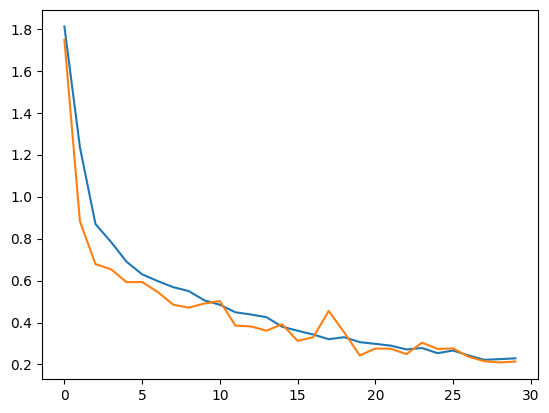

In [31]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.plot(train_loss_list)
ax.plot(test_loss_list)